In [1]:
# ============================================
# Cell 1: Imports, warnings, plotting setup, and project paths
# ============================================

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import linregress

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

# IMPORTANT:
# If the notebook is already inside the project folder, use Path.cwd() directly.
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
REPORT_DIR = PROJECT_ROOT / "reports"
FIG_DIR = REPORT_DIR / "figures"
META_DIR = REPORT_DIR / "metadata"

for folder in [DATA_DIR, PROCESSED_DIR, REPORT_DIR, FIG_DIR, META_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

TRAIN_START = "2015-01-01"
TRAIN_END = "2024-12-31"
LIVE_START = "2025-01-01"
LIVE_END = "2026-03-01"

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data directory: {PROCESSED_DIR}")

Project root: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha
Processed data directory: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed


In [2]:
# ============================================
# Cell 2: Load Phase 1 output
# ============================================

phase_1_parquet = PROCESSED_DIR / "phase_1_master_data.parquet"
phase_1_csv = PROCESSED_DIR / "phase_1_master_data.csv"

print("Looking for files here:")
print("Parquet:", phase_1_parquet)
print("CSV:", phase_1_csv)

if phase_1_parquet.exists():
    df = pd.read_parquet(phase_1_parquet)
    print(f"Loaded Parquet file: {phase_1_parquet}")
elif phase_1_csv.exists():
    df = pd.read_csv(phase_1_csv, index_col=0, parse_dates=True)
    print(f"Loaded CSV file: {phase_1_csv}")
else:
    raise FileNotFoundError(
        "Phase 1 output file was not found. "
        f"Expected one of:\n{phase_1_parquet}\n{phase_1_csv}"
    )

df.index = pd.to_datetime(df.index)
df = df.sort_index()

print("\nPhase 1 dataset shape:")
print(df.shape)

print("\nPhase 1 dataset columns:")
print(df.columns.tolist())

print("\nPhase 1 dataset preview:")
print(df.head())

Looking for files here:
Parquet: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_1_master_data.parquet
CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_1_master_data.csv
Loaded Parquet file: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_1_master_data.parquet

Phase 1 dataset shape:
(3057, 11)

Phase 1 dataset columns:
['spy_adj_close', 'spy_close', 'spy_high', 'spy_low', 'spy_open', 'spy_volume', 'vix_close', 'tnx_close', 'is_train_period', 'is_live_period', 'dataset_partition']

Phase 1 dataset preview:
            spy_adj_close   spy_close    spy_high     spy_low    spy_open  \
Date                                                                        
2014-01-02     148.580261  182.919998  184.070007  182.479996  183.979996   
2014-01-03     148.555939  182.889999  183.600006  182.630005  183.229996   
2014-01-06     148.125412  182.360001  183.559998  182.080002  183.490005   
2014-01-07     149.035126  183

In [3]:
# ============================================
# Cell 3: Validation before feature engineering
# Purpose:
# - Confirm Phase 1 gave us the required market and macro columns
# - Prevent silent downstream failures
# - Make the notebook fail early and clearly if anything is missing
# ============================================

required_phase_1_cols = [
    "spy_open",
    "spy_high",
    "spy_low",
    "spy_close",
    "spy_adj_close",
    "spy_volume",
    "vix_close",
    "tnx_close",
]

missing_phase_1_cols = [col for col in required_phase_1_cols if col not in df.columns]
if missing_phase_1_cols:
    raise ValueError(f"Phase 1 output is missing required columns: {missing_phase_1_cols}")

assert df.index.is_monotonic_increasing, "Index must be sorted ascending."
assert df.index.duplicated().sum() == 0, "Duplicate timestamps are not allowed."

for col in required_phase_1_cols:
    if df[col].isna().any():
        raise ValueError(f"Column '{col}' contains missing values before feature engineering.")

print("Phase 1 validation passed successfully.")

Phase 1 validation passed successfully.


In [4]:
# ============================================
# Cell 4: Helper functions for feature engineering
# Purpose:
# - Centralize reusable calculations
# - Keep all formulas transparent and reproducible
# - Avoid hidden leakage by controlling when lagging happens
# ============================================

def compute_log_return(series: pd.Series) -> pd.Series:
    return np.log(series / series.shift(1))


def compute_rolling_return(series: pd.Series, window: int) -> pd.Series:
    return series.pct_change(window)


def compute_rolling_slope(series: pd.Series, window: int) -> pd.Series:
    """
    Rolling linear regression slope of price over time.
    The slope is estimated using integer time steps 0..window-1.
    This is an interpretable trend-strength feature.
    """
    x = np.arange(window)

    def slope_func(y):
        if np.isnan(y).any():
            return np.nan
        slope, _, _, _, _ = linregress(x, y)
        return slope

    return series.rolling(window=window).apply(slope_func, raw=True)


def compute_true_range(high: pd.Series, low: pd.Series, close: pd.Series) -> pd.Series:
    prev_close = close.shift(1)
    tr_components = pd.concat(
        [
            high - low,
            (high - prev_close).abs(),
            (low - prev_close).abs(),
        ],
        axis=1,
    )
    return tr_components.max(axis=1)


def compute_atr(high: pd.Series, low: pd.Series, close: pd.Series, window: int = 14) -> pd.Series:
    true_range = compute_true_range(high, low, close)
    return true_range.rolling(window=window).mean()


def compute_rsi(series: pd.Series, window: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0.0)
    loss = -delta.clip(upper=0.0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    return rsi


def compute_rolling_zscore(series: pd.Series, window: int) -> pd.Series:
    rolling_mean = series.rolling(window=window).mean()
    rolling_std = series.rolling(window=window).std()
    return (series - rolling_mean) / rolling_std.replace(0, np.nan)


def compute_drawdown_from_price(series: pd.Series, window: int = 252) -> pd.Series:
    rolling_peak = series.rolling(window=window, min_periods=1).max()
    return (series / rolling_peak) - 1.0


def compute_downside_volatility(returns: pd.Series, window: int = 20) -> pd.Series:
    downside_returns = returns.where(returns < 0, 0.0)
    return downside_returns.rolling(window=window).std()


def add_lag_to_feature_block(feature_df: pd.DataFrame, lag: int = 1) -> pd.DataFrame:
    """
    Shift all features by one day so that features observed at t are based only on data available up to t-1.
    This is one of the most important anti-leakage controls in the system.
    """
    return feature_df.shift(lag)


def save_dataframe_with_fallback(df_to_save: pd.DataFrame, parquet_path: Path, csv_path: Path) -> None:
    df_to_save.to_csv(csv_path, index=True)
    try:
        df_to_save.to_parquet(parquet_path, index=True)
        print(f"Saved Parquet: {parquet_path}")
    except Exception as exc:
        print(f"Parquet save skipped due to environment issue: {exc}")
    print(f"Saved CSV: {csv_path}")

In [5]:
# ============================================
# Cell 5: Create all raw feature blocks before lagging
# Purpose:
# - Build predictive inputs from price, trend, volatility, momentum, volume, risk, and macro data
# - Keep the logic transparent and grouped by theme
# - Construct features first, then lag them together as a final anti-leakage step
# ============================================

features = pd.DataFrame(index=df.index)

# -----------------------------
# Price features
# -----------------------------
features["ret_1d"] = df["spy_close"].pct_change(1)
features["log_ret_1d"] = compute_log_return(df["spy_close"])
features["ret_3d"] = compute_rolling_return(df["spy_close"], 3)
features["ret_5d"] = compute_rolling_return(df["spy_close"], 5)
features["ret_10d"] = compute_rolling_return(df["spy_close"], 10)
features["ret_20d"] = compute_rolling_return(df["spy_close"], 20)

# -----------------------------
# Trend features
# -----------------------------
for window in [10, 20, 50, 100, 200]:
    features[f"sma_{window}"] = df["spy_close"].rolling(window).mean()
    features[f"ema_{window}"] = df["spy_close"].ewm(span=window, adjust=False).mean()
    features[f"price_to_sma_{window}"] = df["spy_close"] / features[f"sma_{window}"] - 1.0
    features[f"sma_slope_{window}"] = compute_rolling_slope(df["spy_close"], window)

features["sma_10_20_spread"] = features["sma_10"] / features["sma_20"] - 1.0
features["sma_20_50_spread"] = features["sma_20"] / features["sma_50"] - 1.0
features["sma_50_200_spread"] = features["sma_50"] / features["sma_200"] - 1.0
features["ema_10_20_spread"] = features["ema_10"] / features["ema_20"] - 1.0
features["ema_20_50_spread"] = features["ema_20"] / features["ema_50"] - 1.0

# -----------------------------
# Volatility features
# -----------------------------
features["realized_vol_5"] = features["ret_1d"].rolling(5).std()
features["realized_vol_10"] = features["ret_1d"].rolling(10).std()
features["realized_vol_20"] = features["ret_1d"].rolling(20).std()
features["realized_vol_60"] = features["ret_1d"].rolling(60).std()

features["atr_14"] = compute_atr(df["spy_high"], df["spy_low"], df["spy_close"], window=14)
features["atr_pct_14"] = features["atr_14"] / df["spy_close"]

features["vol_ratio_5_20"] = features["realized_vol_5"] / features["realized_vol_20"]
features["vol_ratio_20_60"] = features["realized_vol_20"] / features["realized_vol_60"]

features["vol_regime_high_20"] = (
    features["realized_vol_20"] > features["realized_vol_20"].rolling(252).median()
).astype(float)

# -----------------------------
# Momentum and mean-reversion features
# -----------------------------
features["rsi_14"] = compute_rsi(df["spy_close"], window=14)
features["zscore_20"] = compute_rolling_zscore(df["spy_close"], window=20)
features["zscore_60"] = compute_rolling_zscore(df["spy_close"], window=60)
features["distance_from_20d_mean"] = df["spy_close"] / df["spy_close"].rolling(20).mean() - 1.0
features["distance_from_50d_mean"] = df["spy_close"] / df["spy_close"].rolling(50).mean() - 1.0
features["distance_from_200d_mean"] = df["spy_close"] / df["spy_close"].rolling(200).mean() - 1.0

# -----------------------------
# Volume features
# -----------------------------
features["volume_sma_20"] = df["spy_volume"].rolling(20).mean()
features["volume_sma_60"] = df["spy_volume"].rolling(60).mean()
features["volume_ratio_20"] = df["spy_volume"] / features["volume_sma_20"]
features["volume_ratio_60"] = df["spy_volume"] / features["volume_sma_60"]
features["volume_zscore_20"] = compute_rolling_zscore(df["spy_volume"], window=20)
features["volume_spike_flag"] = (features["volume_ratio_20"] > 1.5).astype(float)

# -----------------------------
# Risk features
# -----------------------------
features["drawdown_252"] = compute_drawdown_from_price(df["spy_close"], window=252)
features["downside_vol_20"] = compute_downside_volatility(features["ret_1d"], window=20)
features["downside_vol_60"] = compute_downside_volatility(features["ret_1d"], window=60)
features["intraday_range_pct"] = (df["spy_high"] - df["spy_low"]) / df["spy_close"]
features["gap_open_pct"] = (df["spy_open"] / df["spy_close"].shift(1)) - 1.0

# -----------------------------
# Macro features
# -----------------------------
features["vix_level"] = df["vix_close"]
features["vix_ret_1d"] = df["vix_close"].pct_change(1)
features["vix_change_5d"] = df["vix_close"].pct_change(5)
features["vix_zscore_20"] = compute_rolling_zscore(df["vix_close"], window=20)

features["tnx_level"] = df["tnx_close"]
features["tnx_change_1d"] = df["tnx_close"].diff(1)
features["tnx_change_5d"] = df["tnx_close"].diff(5)
features["tnx_zscore_20"] = compute_rolling_zscore(df["tnx_close"], window=20)

# -----------------------------
# Cross-asset interaction features
# -----------------------------
features["spy_vix_ratio"] = df["spy_close"] / df["vix_close"]
features["spy_vix_corr_20"] = features["ret_1d"].rolling(20).corr(features["vix_ret_1d"])
features["spy_tnx_corr_20"] = features["ret_1d"].rolling(20).corr(features["tnx_change_1d"])

print("Raw feature matrix created successfully.")
print(f"Raw feature matrix shape: {features.shape}")
print(features.head())

Raw feature matrix created successfully.
Raw feature matrix shape: (3057, 68)
              ret_1d  log_ret_1d    ret_3d  ret_5d  ret_10d  ret_20d  sma_10  \
Date                                                                           
2014-01-02       NaN         NaN       NaN     NaN      NaN      NaN     NaN   
2014-01-03 -0.000164   -0.000164       NaN     NaN      NaN      NaN     NaN   
2014-01-06 -0.002898   -0.002902       NaN     NaN      NaN      NaN     NaN   
2014-01-07  0.006142    0.006123  0.003061     NaN      NaN      NaN     NaN   
2014-01-08  0.000218    0.000218  0.003445     NaN      NaN      NaN     NaN   

                ema_10  price_to_sma_10  sma_slope_10  ...  vix_ret_1d  \
Date                                                   ...               
2014-01-02  182.919998              NaN           NaN  ...         NaN   
2014-01-03  182.914544              NaN           NaN  ...   -0.033029   
2014-01-06  182.813718              NaN           NaN  ...   -0.0

In [6]:
# ============================================
# Cell 6: Lag all features, align with dataset, and remove leakage rows
# Purpose:
# - Shift every engineered feature by one day
# - Ensure signals at time t are based only on information available by the close of t-1
# - Drop early rows created by rolling windows and the lag itself
# ============================================

lagged_features = add_lag_to_feature_block(features, lag=1)

feature_dataset = df.copy()
feature_dataset = feature_dataset.join(lagged_features, how="left")

# Identify engineered feature columns only.
engineered_feature_cols = lagged_features.columns.tolist()

# Remove rows where engineered features are unavailable due to rolling windows or lagging.
feature_dataset = feature_dataset.dropna(subset=engineered_feature_cols).copy()

# Keep only rows inside the intended research horizon once features are valid.
feature_dataset = feature_dataset[
    (feature_dataset.index >= pd.Timestamp(TRAIN_START)) &
    (feature_dataset.index <= pd.Timestamp(LIVE_END))
].copy()

# Rebuild the partition columns cleanly after trimming.
feature_dataset["is_train_period"] = (
    (feature_dataset.index >= pd.Timestamp(TRAIN_START)) &
    (feature_dataset.index <= pd.Timestamp(TRAIN_END))
)

feature_dataset["is_live_period"] = (
    (feature_dataset.index >= pd.Timestamp(LIVE_START)) &
    (feature_dataset.index <= pd.Timestamp(LIVE_END))
)

feature_dataset["dataset_partition"] = np.select(
    [
        feature_dataset["is_train_period"],
        feature_dataset["is_live_period"],
    ],
    [
        "train",
        "live",
    ],
    default="unused"
)

print("Lagged feature dataset created successfully.")
print(f"Final feature dataset shape: {feature_dataset.shape}")
print("\nPartition counts:")
print(feature_dataset["dataset_partition"].value_counts(dropna=False))

Lagged feature dataset created successfully.
Final feature dataset shape: (2805, 79)

Partition counts:
dataset_partition
train    2516
live      289
Name: count, dtype: int64


In [7]:
# ============================================
# Cell 7: Feature validation, diagnostics, and summary statistics
# Purpose:
# - Confirm feature integrity before moving into target construction
# - Verify no missing values remain in the engineered inputs
# - Catch any infinite values or structural problems now rather than later
# ============================================

assert feature_dataset.index.is_monotonic_increasing, "Feature dataset index must be sorted ascending."
assert feature_dataset.index.duplicated().sum() == 0, "Feature dataset contains duplicate timestamps."

missing_feature_values = feature_dataset[engineered_feature_cols].isna().sum().sum()
if missing_feature_values != 0:
    raise ValueError(f"Engineered features still contain missing values: {missing_feature_values}")

infinite_counts = np.isinf(feature_dataset[engineered_feature_cols].to_numpy()).sum()
if infinite_counts != 0:
    raise ValueError(f"Engineered features contain infinite values: {infinite_counts}")

if not feature_dataset["is_train_period"].any():
    raise ValueError("No training rows are present after feature alignment.")

if not feature_dataset["is_live_period"].any():
    raise ValueError("No live rows are present after feature alignment.")

feature_summary = feature_dataset[engineered_feature_cols].describe().T
print(feature_summary.head(20))

print("\nFeature validation passed successfully.")
print(f"Number of engineered features: {len(engineered_feature_cols)}")

                  count        mean         std         min         25%  \
ret_1d           2805.0    0.000491    0.011205   -0.109424   -0.003771   
log_ret_1d       2805.0    0.000428    0.011229   -0.115887   -0.003779   
ret_3d           2805.0    0.001449    0.018242   -0.125784   -0.006587   
ret_5d           2805.0    0.002400    0.022884   -0.179693   -0.007354   
ret_10d          2805.0    0.004800    0.031350   -0.232884   -0.008304   
ret_20d          2805.0    0.009627    0.043436   -0.313902   -0.009495   
sma_10           2805.0  364.413452  136.083092  187.640001  249.307999   
ema_10           2805.0  364.411744  136.043839  187.092690  249.851471   
price_to_sma_10  2805.0    0.001980    0.017040   -0.145623   -0.004798   
sma_slope_10     2805.0    0.170769    1.289535   -8.510970   -0.338001   
sma_20           2805.0  363.553031  135.482943  188.390000  251.180500   
ema_20           2805.0  363.550939  135.397107  189.225900  252.053762   
price_to_sma_20  2805.0  

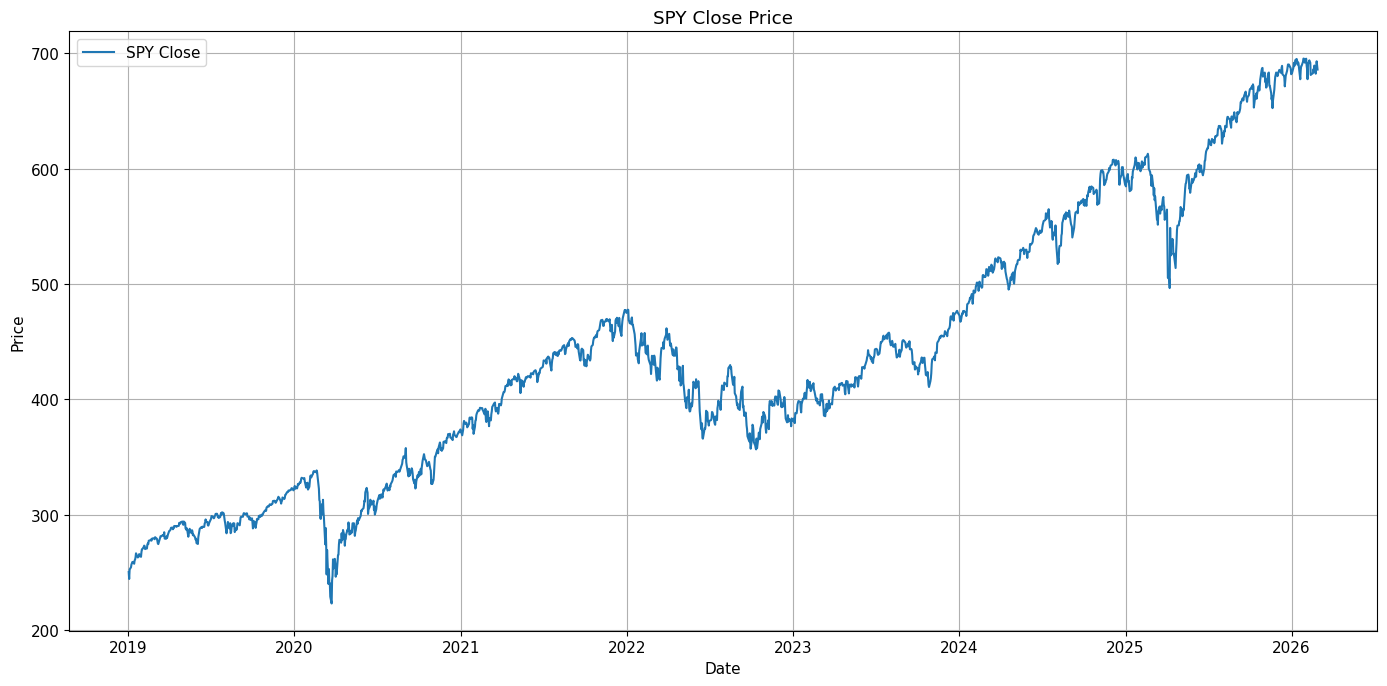

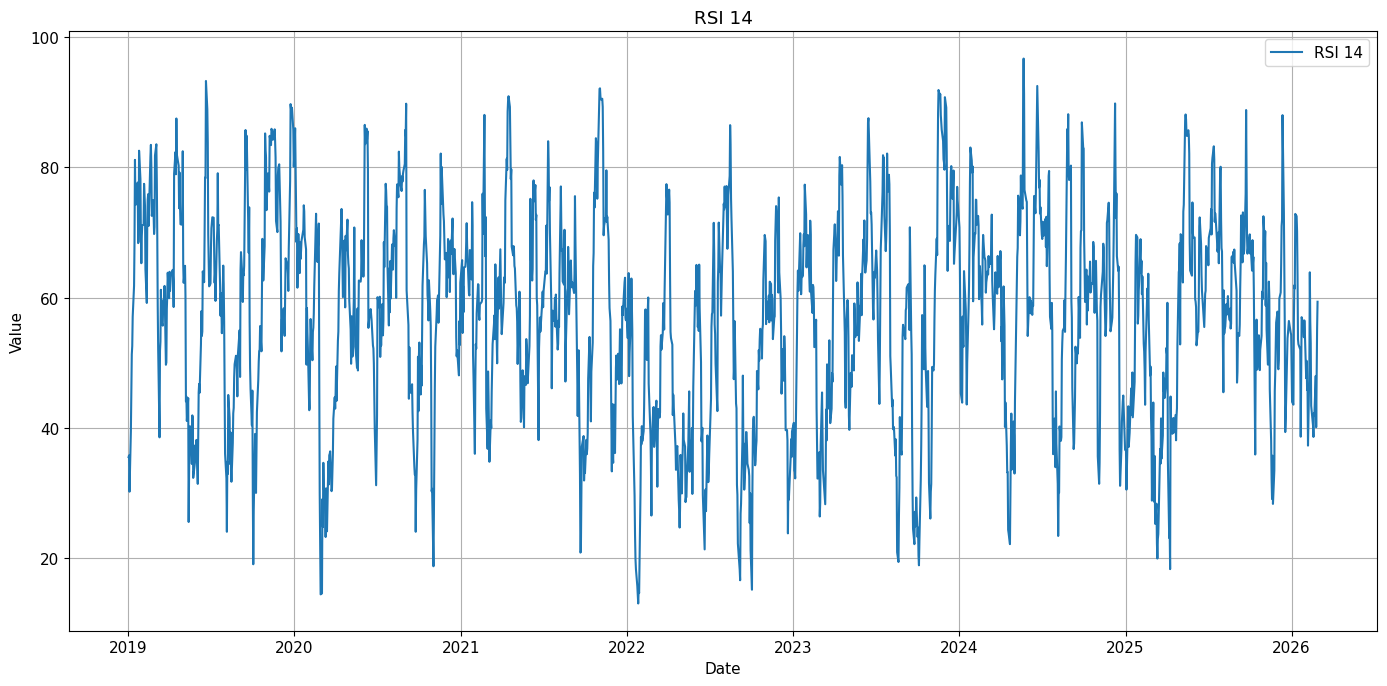

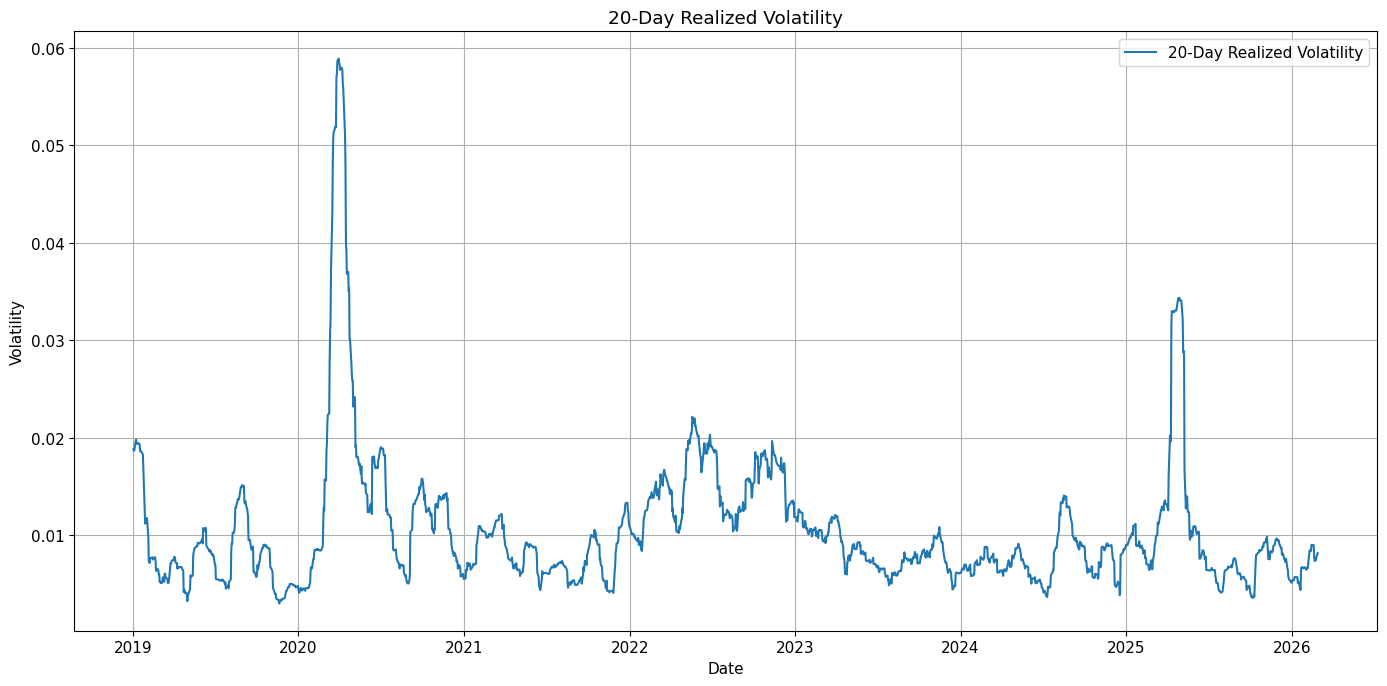

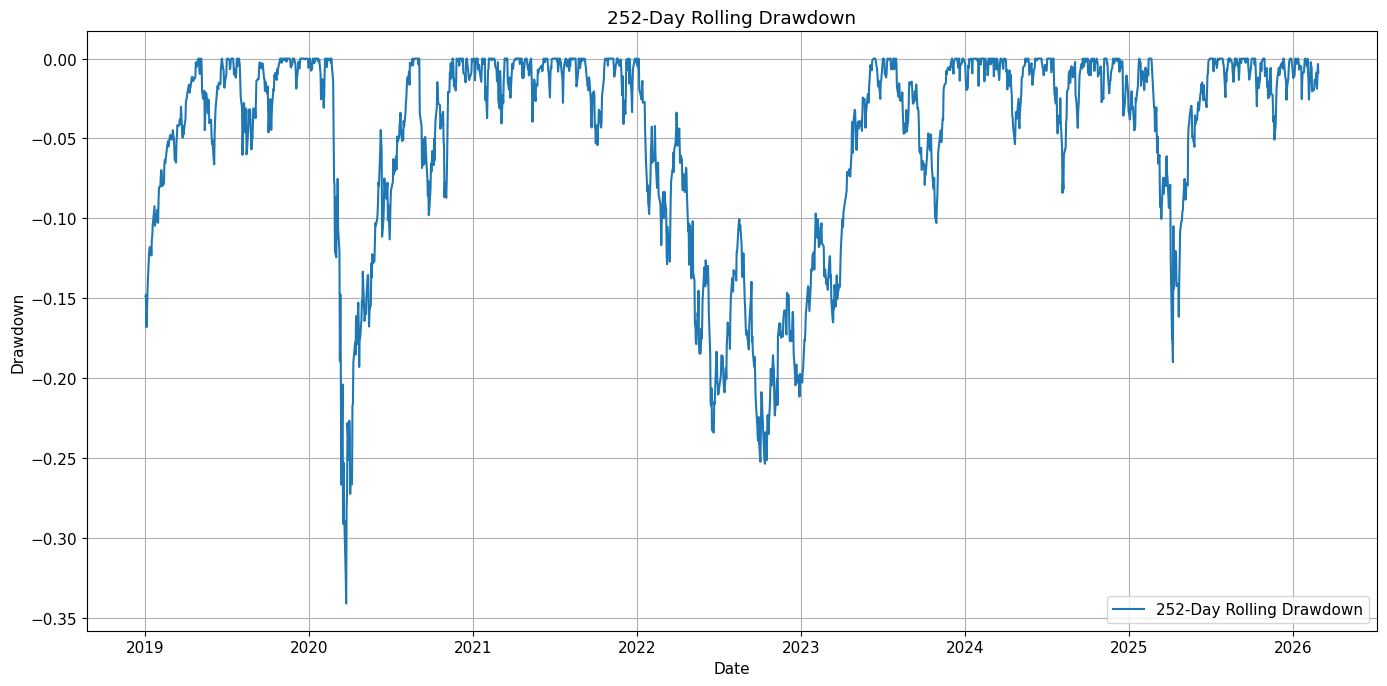

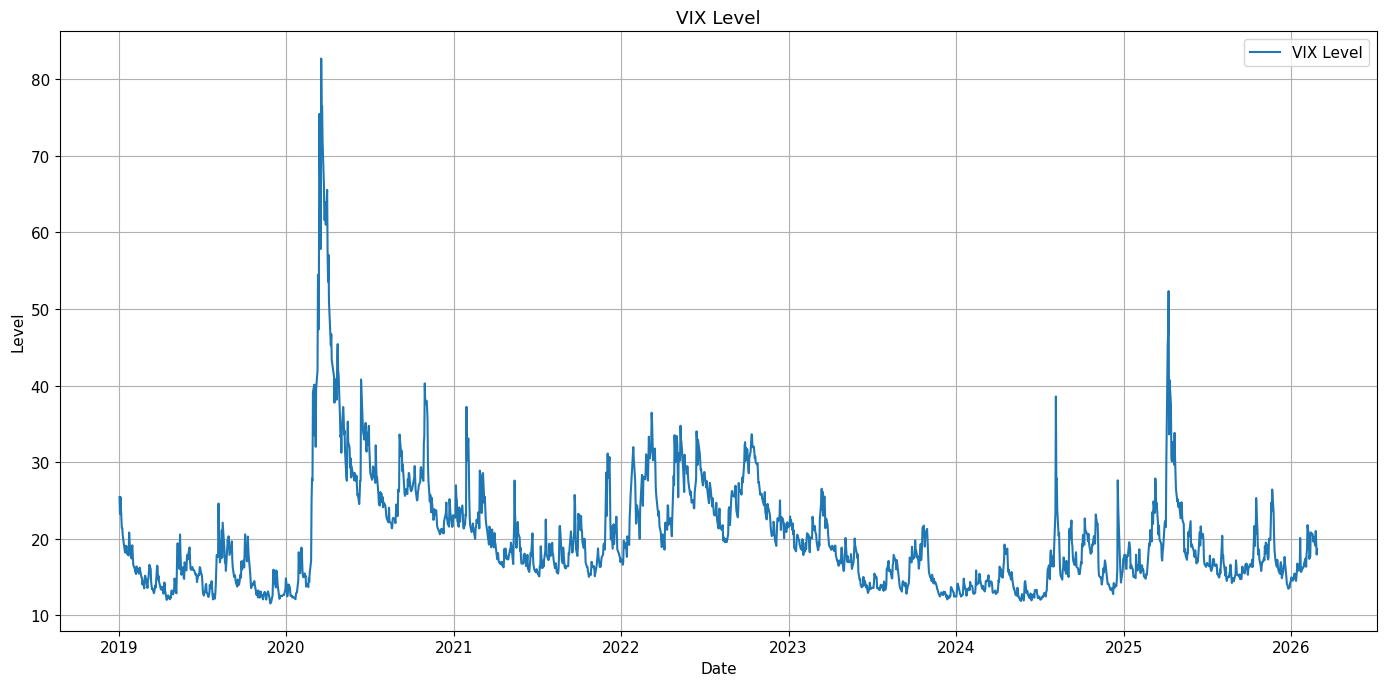

In [8]:
# ============================================
# Cell 8: Visual inspection of selected features
# Purpose:
# - Plot a small set of representative features to verify they behave sensibly over time
# - Provide a formal visual audit before the modeling phases
# - Save the figures for later reporting and notebook review
# ============================================

plot_start_date = "2019-01-01"
plot_data = feature_dataset.loc[plot_start_date:].copy()

fig, ax = plt.subplots()
ax.plot(plot_data.index, plot_data["spy_close"], label="SPY Close")
ax.set_title("SPY Close Price")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "phase_2_spy_close.png", dpi=150)
plt.show()

fig, ax = plt.subplots()
ax.plot(plot_data.index, plot_data["rsi_14"], label="RSI 14")
ax.set_title("RSI 14")
ax.set_xlabel("Date")
ax.set_ylabel("Value")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "phase_2_rsi_14.png", dpi=150)
plt.show()

fig, ax = plt.subplots()
ax.plot(plot_data.index, plot_data["realized_vol_20"], label="20-Day Realized Volatility")
ax.set_title("20-Day Realized Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Volatility")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "phase_2_realized_vol_20.png", dpi=150)
plt.show()

fig, ax = plt.subplots()
ax.plot(plot_data.index, plot_data["drawdown_252"], label="252-Day Rolling Drawdown")
ax.set_title("252-Day Rolling Drawdown")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "phase_2_drawdown_252.png", dpi=150)
plt.show()

fig, ax = plt.subplots()
ax.plot(plot_data.index, plot_data["vix_level"], label="VIX Level")
ax.set_title("VIX Level")
ax.set_xlabel("Date")
ax.set_ylabel("Level")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "phase_2_vix_level.png", dpi=150)
plt.show()

In [9]:
# ============================================
# Cell 9: Save Phase 2 outputs for Phase 3
# ============================================

from pathlib import Path
import json

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
META_DIR = PROJECT_ROOT / "reports" / "metadata"

for folder in [DATA_DIR, PROCESSED_DIR, META_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Current working directory:")
print(PROJECT_ROOT)

print("\nSaving Phase 2 files to:")
print(PROCESSED_DIR)

phase_2_csv_path = PROCESSED_DIR / "phase_2_feature_data.csv"
phase_2_parquet_path = PROCESSED_DIR / "phase_2_feature_data.parquet"

feature_dataset.to_csv(phase_2_csv_path, index=True)
print(f"Saved CSV: {phase_2_csv_path}")

try:
    feature_dataset.to_parquet(phase_2_parquet_path, index=True)
    print(f"Saved Parquet: {phase_2_parquet_path}")
except Exception as e:
    print(f"Parquet save skipped: {e}")

phase_2_metadata = {
    "phase": "Phase 2 - Feature Engineering Layer",
    "source_notebook": "2 - Feature Engineering Layer.ipynb",
    "row_count": int(len(feature_dataset)),
    "column_count": int(feature_dataset.shape[1]),
    "feature_count": int(len(engineered_feature_cols)),
    "feature_columns": engineered_feature_cols,
    "start_date": str(feature_dataset.index.min().date()),
    "end_date": str(feature_dataset.index.max().date()),
    "train_rows": int(feature_dataset["is_train_period"].sum()),
    "live_rows": int(feature_dataset["is_live_period"].sum()),
}

phase_2_metadata_path = META_DIR / "phase_2_metadata.json"
with open(phase_2_metadata_path, "w", encoding="utf-8") as f:
    json.dump(phase_2_metadata, f, indent=4)

print(f"Saved metadata: {phase_2_metadata_path}")

print("\nFiles now in processed directory:")
for f in PROCESSED_DIR.iterdir():
    print(f.name)

Current working directory:
c:\Users\Tyler\Regime-Aware Risk Integrated Alpha

Saving Phase 2 files to:
c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed
Saved CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_2_feature_data.csv
Saved Parquet: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_2_feature_data.parquet
Saved metadata: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\reports\metadata\phase_2_metadata.json

Files now in processed directory:
phase_1_master_data.csv
phase_1_master_data.parquet
phase_2_feature_data.csv
phase_2_feature_data.parquet


In [11]:
# ============================================
# Cell 10: Phase 3 loader snippet
# ============================================

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

phase_2_parquet = PROCESSED_DIR / "phase_2_feature_data.parquet"
phase_2_csv = PROCESSED_DIR / "phase_2_feature_data.csv"

print("Looking for Phase 2 files:")
print("Parquet:", phase_2_parquet)
print("CSV:", phase_2_csv)

if phase_2_parquet.exists():
    phase_2_data = pd.read_parquet(phase_2_parquet)
    print("Loaded Parquet file")
elif phase_2_csv.exists():
    phase_2_data = pd.read_csv(phase_2_csv, index_col=0, parse_dates=True)
    print("Loaded CSV file")
else:
    raise FileNotFoundError(
        "Phase 2 data file was not found. "
        f"Expected one of:\n{phase_2_parquet}\n{phase_2_csv}"
    )

phase_2_data.index = pd.to_datetime(phase_2_data.index)
phase_2_data = phase_2_data.sort_index()

print("\nLoaded Phase 2 dataset preview:")
print(phase_2_data.head())

Looking for Phase 2 files:
Parquet: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_2_feature_data.parquet
CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_2_feature_data.csv
Loaded Parquet file

Loaded Phase 2 dataset preview:
            spy_adj_close   spy_close    spy_high     spy_low    spy_open  \
Date                                                                        
2015-01-02     170.125000  205.429993  206.880005  204.179993  206.380005   
2015-01-05     167.052612  201.720001  204.369995  201.350006  204.169998   
2015-01-06     165.479187  199.820007  202.720001  198.860001  202.089996   
2015-01-07     167.541229  202.309998  202.720001  200.880005  201.419998   
2015-01-08     170.514236  205.899994  206.160004  203.990005  204.009995   

            spy_volume  vix_close  tnx_close  is_train_period  is_live_period  \
Date                                                                            
2015-01-02   1214659